In [ ]:
import os
import shutil
from random import shuffle
from tensorflow.keras.preprocessing.image import ImageDataGenerator

separar conjunto de treino / validação / teste


In [ ]:
origem = 'train'  
base_destino = 'dados'

gatos = [f for f in os.listdir(origem) if f.startswith('cat') ]
cachorros = [f for f in os.listdir(origem) if f.startswith('dog') ]

shuffle(gatos)
shuffle(cachorros)

num_gatos = len(gatos)
num_cachorros = len(cachorros)

# 70% treino - 15% validação - 15% teste
def split_indices(total, train_ratio=0.7, val_ratio=0.15):
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)
    return train_end, val_end

train_end_g, val_end_g = split_indices(num_gatos)
train_end_c, val_end_c = split_indices(num_cachorros)

def mover_arquivos(lista_arquivos, treino_end, val_end, label):
    for f in lista_arquivos[:treino_end]:
        shutil.move(os.path.join(origem, f), os.path.join(base_destino, 'treino', label, f))
    for f in lista_arquivos[treino_end:val_end]:
        shutil.move(os.path.join(origem, f), os.path.join(base_destino, 'validacao', label, f))
    for f in lista_arquivos[val_end:]:
        shutil.move(os.path.join(origem, f), os.path.join(base_destino, 'teste', label, f))

mover_arquivos(gatos, train_end_g, val_end_g, 'gatos')
mover_arquivos(cachorros, train_end_c, val_end_c, 'cachorros')

print('Arquivos movidos e organizados com sucesso')


Arquivos movidos e organizados com sucesso


Realização de Pre-processamento e aumento de dados 

In [ ]:
# Definir o tamanho da imagem e o tamanho do lote (batch size)
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Gerando novas imagens a partir das que temos para treino, aplicando transormações aleatorias(rotação, zoom, etc.).
#  Isso torna o modelo mais robusto e evita o superajuste (overfitting).
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Realizando normalização na escala
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'dados/treino',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary' # uso do binary, pois estamos nesse caso falando apenas de duas opções de classe (cachorro ou gato)
)

validation_generator = test_datagen.flow_from_directory(
    'dados/validacao',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    'dados/teste',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False 
)

Found 17513 images belonging to 2 classes.
Found 3746 images belonging to 2 classes.
Found 3741 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # 1º Bloco Convolucional
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    # 2º Bloco Convolucional
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # 3º Bloco Convolucional
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Camadas de Classificação
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5), # Camada de Dropout para regularização
    Dense(1, activation='sigmoid') # Saída binária
])

# Compilar o modelo
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/home/gabriel/gabriel/IA-PUC/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1749270190.342113   11282 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1749270190.344411   11282 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 50

history = model.fit(
    train_generator,
    epochs=EPOCHS, 
    validation_data=validation_generator
)

model.save('modelo_caes_gatos.h5')

/home/gabriel/gabriel/IA-PUC/venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 281s 504ms/step - accuracy: 0.5508 - loss: 0.6972 - val_accuracy: 0.6773 - val_loss: 0.5996
Epoch 2/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 314s 494ms/step - accuracy: 0.6447 - loss: 0.6343 - val_accuracy: 0.7189 - val_loss: 0.5767
Epoch 3/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 234s 427ms/step - accuracy: 0.6839 - loss: 0.5951 - val_accuracy: 0.7621 - val_loss: 0.4991
Epoch 4/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 1702s 3s/step - accuracy: 0.7158 - loss: 0.5554 - val_accuracy: 0.7787 - val_loss: 0.4690
Epoch 5/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 211s 385ms/step - accuracy: 0.7266 - loss: 0.5359 - val_accuracy: 0.7694 - val_loss: 0.4828
Epoch 6/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 188s 342ms/step - accuracy: 0.7407 - loss: 0.5172 - val_accuracy: 0.8049 - val_loss: 0.4246
Epoch 7/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 207s 378ms/step - accuracy: 0.7604 - loss: 0.4948 - val_accuracy: 0.7993 - val_loss: 0.4462
Epoch 8/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 202s 368ms/step - accuracy: 0.7783 - l

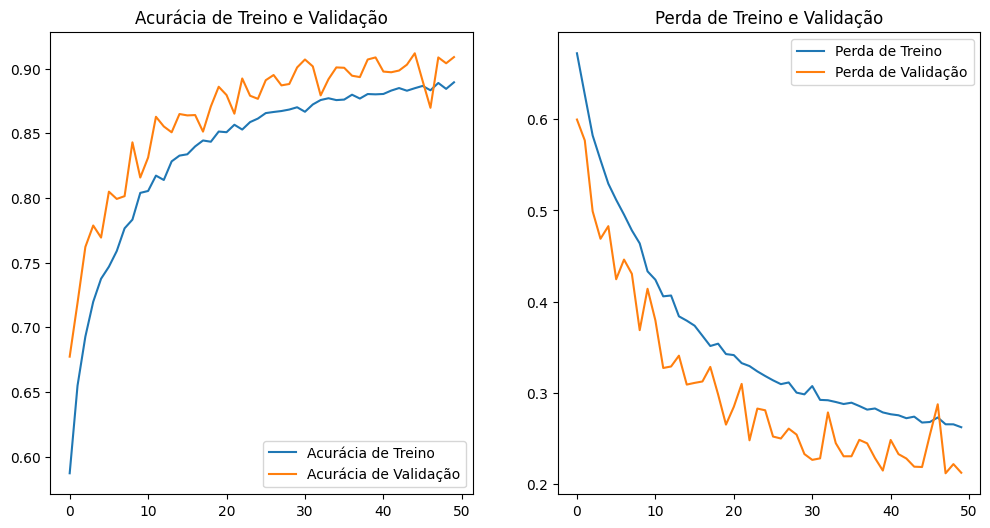

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, label='Acurácia de Validação')
plt.legend(loc='lower right')
plt.title('Acurácia de Treino e Validação')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Perda de Treino')
plt.plot(epochs_range, val_loss, label='Perda de Validação')
plt.legend(loc='upper right')
plt.title('Perda de Treino e Validação')
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

Y_pred = model.predict(test_generator)
y_pred = np.round(Y_pred) 

# Obter as classes verdadeiras
y_true = test_generator.classes

print("Relatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=['Cachorro', 'Gato']))

117/117 ━━━━━━━━━━━━━━━━━━━━ 13s 113ms/step
Relatório de Classificação:
              precision    recall  f1-score   support

    Cachorro       0.86      0.96      0.91      1854
        Gato       0.96      0.85      0.90      1887

    accuracy                           0.90      3741
   macro avg       0.91      0.90      0.90      3741
weighted avg       0.91      0.90      0.90      3741



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
É um GATO com 99.80% de certeza.


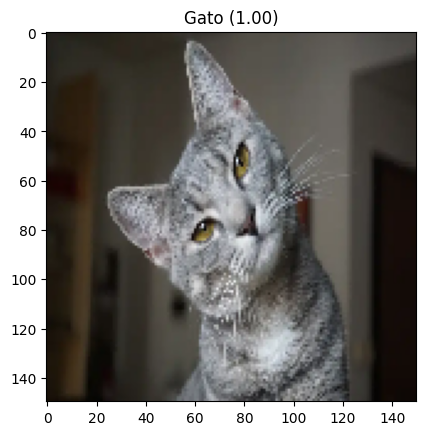

In [22]:
from tensorflow.keras.preprocessing import image

def classify_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array)[0][0]

    plt.imshow(img)
    # Se a predição for < 0.5, é a classe 0 (Cachorro)
    if prediction < 0.5:
        plt.title(f"Cachorro ({1-prediction:.2f})")
        print(f"É um CACHORRO com {100 * (1-prediction):.2f}% de certeza.")
    # Senão, é a classe 1 (Gato)
    else:
        plt.title(f"Gato ({prediction:.2f})")
        print(f"É um GATO com {100 * prediction:.2f}% de certeza.")
    plt.show()

classify_image('/home/gabriel/gabriel/IA-PUC/Lista12/gato.jpg')